In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [40]:
# Read the .csv file
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
path = root + "experiments_s1.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        df[column] = [np.array(eval(i)) for i in df[column].values]
        
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['train_S1_p']
Task

['domainbody' 'backward' 'known' 'full' 'domain']
Grounder

['complex' 'distmult' 'transe']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['no_reasoner' 'dcr' 'r2n' 'sbr' 'rnm']
Model_name



In [57]:
results
split_df(results)


(Grounder      backward     domain  domainbody       full      known
 Model_name                                                         
 dcr          30.245568  85.683430   41.403434  61.697458  24.914323
 no_reasoner  24.331310  61.565661   23.683077  23.012681  25.641498
 r2n          30.339196  89.094945   44.647157  64.875650  24.074545
 rnm          25.701340  57.859514   25.984719  33.013047  21.284067
 sbr          25.636525  57.914574   27.786730  41.363888  22.069867,
 Grounder     backward     domain  domainbody       full     known
 Model_name                                                       
 dcr          2.025903  54.028038    0.706377   8.789504  2.874463
 no_reasoner  2.003406  63.721418    1.732989   1.322455  6.499956
 r2n          1.529698  55.309681    1.198200   9.332213  2.426741
 rnm          2.226921  44.046700    0.794388   5.013609  0.553064
 sbr          1.020274  43.101305    3.717869  13.992355  2.363468)

In [41]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

In [43]:
df[df['Model_name'] == 'no_reasoner']

,Task,Grounder,KGE,EmbedSize,WeightLoss_Task,Reasoner_depth,Model_name,Time,train_loss,train_concept_loss,...,test_concept_mrr,test_concept_hits@1@1,test_concept_hits@3@3,test_concept_hits@5@5,test_concept_hits@10@10,test_task_mrr,test_task_hits@1@1,test_task_hits@3@3,test_task_hits@5@5,"test_task_hits@10@10,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,train_S1_p,domainbody,complex,100,0.5,1,no_reasoner,"[27.328875494003295, 2.1582102287173583]","[2.5768, 0.0001]","[0.012, 0.0002]",...,"[0.9215, 0.0099]","[0.88, 0.0126]","[0.944, 0.0233]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
5,train_S1_p,domainbody,distmult,100,0.5,1,no_reasoner,"[23.54277410507202, 0.7410592020230454]","[2.5769, 0.0001]","[0.0121, 0.0001]",...,"[0.9237, 0.0121]","[0.892, 0.016]","[0.932, 0.0271]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
10,train_S1_p,domainbody,transe,100,0.5,1,no_reasoner,"[23.683077335357666, 1.7329887118229268]","[3.3469, 0.0019]","[1.5521, 0.0039]",...,"[0.7293, 0.0385]","[0.58, 0.0537]","[0.844, 0.0445]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
15,train_S1_p,backward,complex,100,0.5,1,no_reasoner,"[28.28896870613098, 1.6313267049893474]","[2.5768, 0.0001]","[0.012, 0.0002]",...,"[0.9215, 0.0099]","[0.88, 0.0126]","[0.944, 0.0233]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
20,train_S1_p,backward,distmult,100,0.5,1,no_reasoner,"[25.089077043533326, 1.449886009254306]","[2.5769, 0.0001]","[0.0121, 0.0001]",...,"[0.9237, 0.0121]","[0.892, 0.016]","[0.932, 0.0271]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
25,train_S1_p,backward,transe,100,0.5,1,no_reasoner,"[24.331309509277343, 2.003406035908735]","[3.3469, 0.0019]","[1.5521, 0.0039]",...,"[0.7293, 0.0385]","[0.58, 0.0537]","[0.844, 0.0445]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
30,train_S1_p,known,complex,100,0.5,1,no_reasoner,"[29.60445523262024, 1.495648995216251]","[2.5768, 0.0001]","[0.012, 0.0002]",...,"[0.9215, 0.0099]","[0.88, 0.0126]","[0.944, 0.0233]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
35,train_S1_p,known,distmult,100,0.5,1,no_reasoner,"[22.285904836654662, 2.7353508153536503]","[2.5769, 0.0001]","[0.0121, 0.0001]",...,"[0.9237, 0.0121]","[0.892, 0.016]","[0.932, 0.0271]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
40,train_S1_p,known,transe,100,0.5,1,no_reasoner,"[25.641497945785524, 6.49995554107884]","[3.3469, 0.0019]","[1.5521, 0.0039]",...,"[0.7293, 0.0385]","[0.58, 0.0537]","[0.844, 0.0445]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
45,train_S1_p,full,complex,100,0.5,1,no_reasoner,"[28.112027311325072, 3.6298037998627355]","[2.5768, 0.0001]","[0.012, 0.0002]",...,"[0.9215, 0.0099]","[0.88, 0.0126]","[0.944, 0.0233]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"


# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [6]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
cols = 'Grounder'
rows = 'Model_name'
metric = 'test_task_mrr'
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
for metric in ['test_task_mrr', 'Time']:
    for KGE in ['complex', 'distmult', 'transe']:
        # filter the df
        results = df.loc[ (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
        # take only the columns grounder, model, test_task_mrr, test_concept_mrr
        results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
        # put the model_name as colums
        results = results.pivot(index=rows, columns=cols, values=metric)
        if metric == 'test_task_mrr':
            # in the column no_reasoner, put the values of the column test_concept_mrr
            substitute = df.loc[ (df['KGE'] == 'complex') & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
            substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
            # substitute the values in the table
            results.loc[baseline_model] = substitute.loc[baseline_model] 

        # print(results) 
        # with open(csv_dir, 'a') as f:
        #     f.write('\n KGE : ,' + KGE + ', Metric: ,' + metric)
        #     f.write('\n ')
        # results.to_csv(csv_dir, mode='a', header=True)  
results

Grounder,backward,domain,domainbody,full,known
Model_name,,,,,
dcr,"[30.245567560195923, 2.0259030494826664]","[85.68342971801758, 54.028037954384125]","[41.4034342288971, 0.7063774047142523]","[61.69745836257935, 8.789503514700902]","[24.914322662353516, 2.8744628825428817]"
no_reasoner,"[24.331309509277343, 2.003406035908735]","[61.56566052436828, 63.721418097992135]","[23.683077335357666, 1.7329887118229268]","[23.0126811504364, 1.3224554302378349]","[25.641497945785524, 6.49995554107884]"
r2n,"[30.339196348190306, 1.52969794872873]","[89.09494500160217, 55.30968099592316]","[44.64715723991394, 1.198199831527011]","[64.87564964294434, 9.33221348957898]","[24.074545240402223, 2.4267409001272195]"
rnm,"[25.70134034156799, 2.2269212797910876]","[57.859513711929324, 44.04669978184587]","[25.984719133377077, 0.794388494542248]","[33.01304731369019, 5.013609413148241]","[21.28406662940979, 0.5530643474367979]"
sbr,"[25.636524772644044, 1.0202740796379426]","[57.91457357406616, 43.101304543217914]","[27.786730146408082, 3.717869455926423]","[41.36388802528381, 13.992355236440874]","[22.06986713409424, 2.3634677688233214]"


In [61]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

In [52]:
# select the first row by name = r2n
df_mean

Grounder,backward,domain,domainbody,full,known
Model_name,,,,,
dcr,0.8041,0.7585,0.7674,0.7554,0.9893
no_reasoner,0.7293,0.7293,0.7293,0.7293,0.7293
r2n,0.7408,0.7244,0.7408,0.7244,0.7408
rnm,0.7290,0.7039,0.7491,0.7039,0.7395
sbr,0.7303,0.7061,0.7337,0.7061,0.7621


Grounder     backward  domain  domainbody    full   known
Model_name                                               
dcr            0.9206  0.9221      0.9170  0.9199  0.9424
no_reasoner    0.9215  0.9215      0.9215  0.9215  0.9215
r2n            0.9224  0.9281      0.9247  0.9281  0.9940
rnm            0.9317  0.9370      0.9317  0.9370  0.9263
sbr            0.9617  0.9567      0.9611  0.9567  0.9590
0.9215


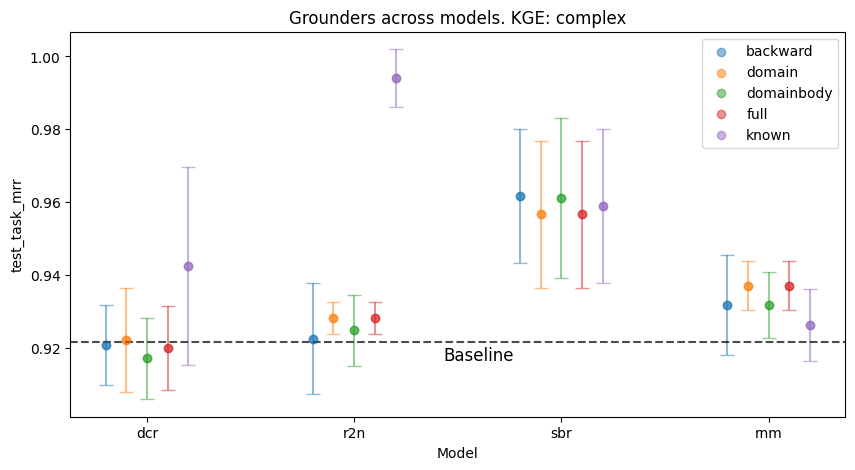

Grounder     backward  domain  domainbody    full   known
Model_name                                               
dcr            0.9141  0.9034      0.9130  0.9063  0.9557
no_reasoner    0.9237  0.9237      0.9237  0.9237  0.9237
r2n            0.9127  0.9166      0.9152  0.9166  1.0000
rnm            0.9205  0.9140      0.9241  0.9140  0.9260
sbr            0.9522  0.9452      0.9549  0.9452  0.9657
0.9237


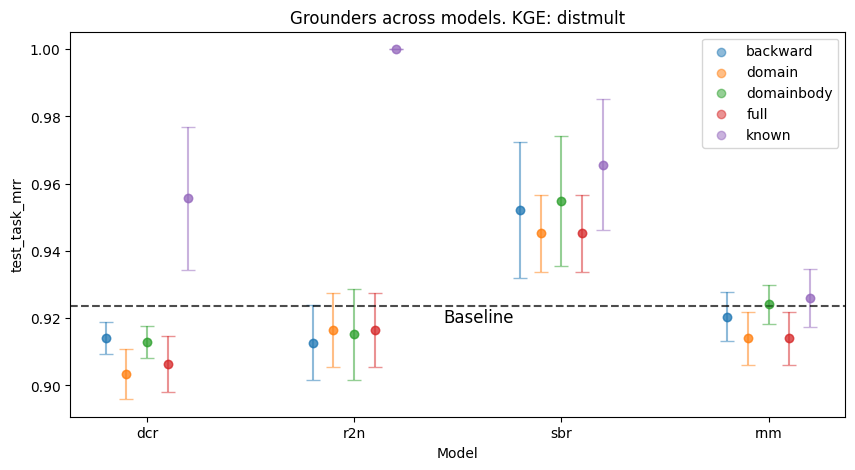

Grounder     backward  domain  domainbody    full   known
Model_name                                               
dcr            0.8041  0.7585      0.7674  0.7554  0.9893
no_reasoner    0.7293  0.7293      0.7293  0.7293  0.7293
r2n            0.7408  0.7244      0.7408  0.7244  0.7408
rnm            0.7290  0.7039      0.7491  0.7039  0.7395
sbr            0.7303  0.7061      0.7337  0.7061  0.7621
0.7293


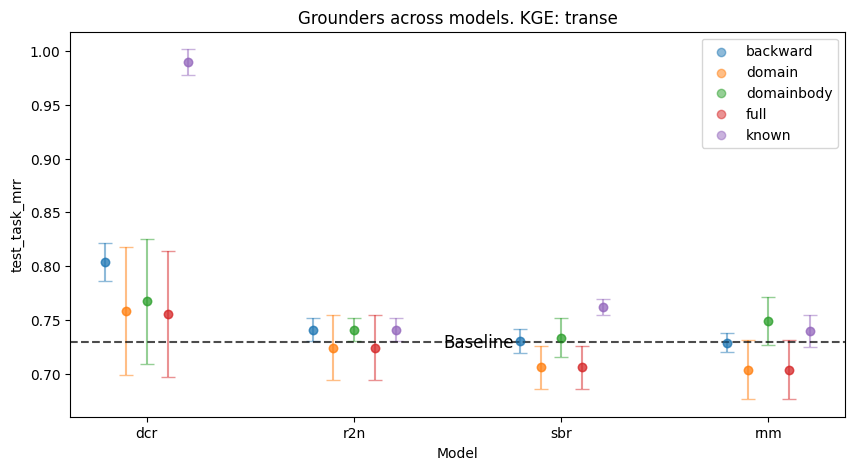

Grounder      backward     domain  domainbody       full      known
Model_name                                                         
dcr          34.584192  76.681300   43.758101  66.451936  32.151126
no_reasoner  28.288969  46.694435   27.328875  28.112027  29.604455
r2n          34.980058  81.476191   45.894347  71.837570  30.623417
rnm          30.756798  62.969856   30.905685  41.310982  26.387650
sbr          29.935029  53.597537   32.890351  41.805246  35.508503


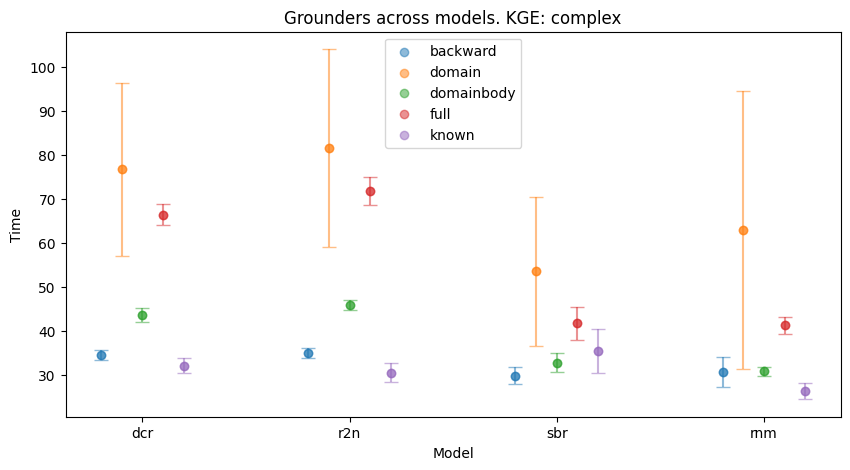

Grounder      backward     domain  domainbody       full      known
Model_name                                                         
dcr          32.742154  79.072829   44.730242  63.664297  26.842208
no_reasoner  25.089077  47.710751   23.542774  26.485506  22.285905
r2n          31.604431  91.597193   47.522618  62.568656  24.444277
rnm          26.952708  53.722347   27.251998  33.150173  22.572521
sbr          26.232041  35.611931   26.735055  29.931431  22.405999


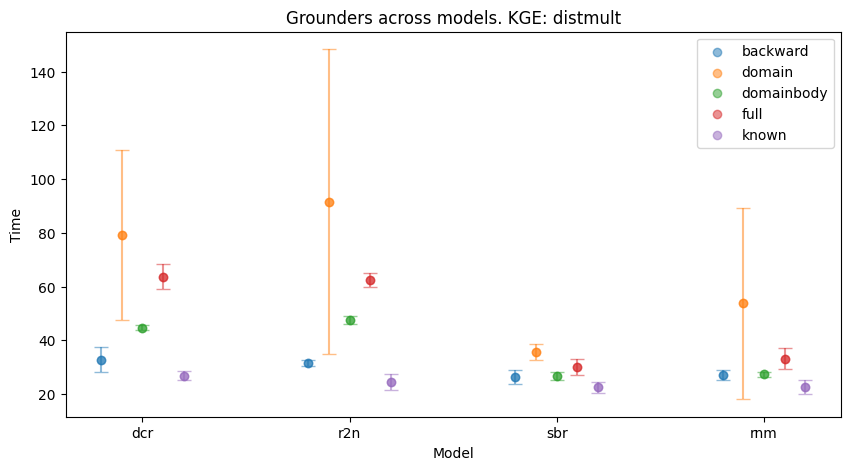

Grounder      backward     domain  domainbody       full      known
Model_name                                                         
dcr          30.245568  85.683430   41.403434  61.697458  24.914323
no_reasoner  24.331310  61.565661   23.683077  23.012681  25.641498
r2n          30.339196  89.094945   44.647157  64.875650  24.074545
rnm          25.701340  57.859514   25.984719  33.013047  21.284067
sbr          25.636525  57.914574   27.786730  41.363888  22.069867


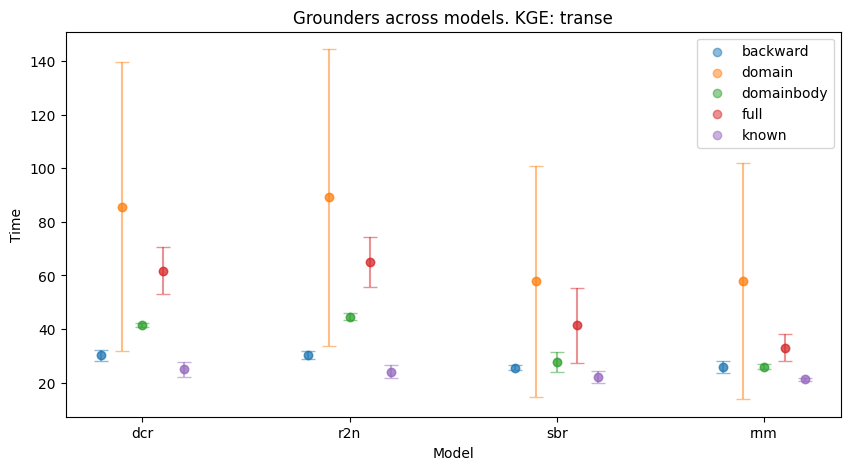

In [60]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\"
cols = 'Grounder'
rows = 'Model_name'
metric = 'test_task_mrr'
models = ['dcr','r2n','sbr','rnm']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
for metric in ['test_task_mrr','Time']:
    for KGE in ['complex', 'distmult', 'transe']:
        # filter the df
        results = df.loc[ (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
        # take only the columns grounder, model, test_task_mrr, test_concept_mrr
        results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
        # put the model_name as colums
        results = results.pivot(index=rows, columns=cols, values=metric)

        if metric == 'test_task_mrr':
            # in the column no_reasoner, put the values of the column test_concept_mrr
            substitute = df.loc[ (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
            substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
            # substitute the values in the table
            results.loc[baseline_model] = substitute.loc[baseline_model]
        df_mean, df_std = split_df(results)
        print(df_mean)
        # Remove no reasoner and include a line where it is written baseline
        plt.figure(figsize=(10,5))
        for i,grounder in enumerate(df_mean.columns):
            plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
            plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
        if metric == 'test_task_mrr':
            plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
            plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
            print(df_mean.loc[baseline_model].values[0])
        plt.legend()
        plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
        plt.ylabel(metric)
        plt.xlabel('Model')
        plt.title(f'Grounders across models. KGE: {KGE}')
        plt.show()
        # SAVE THE FIGURE
        # plt.savefig(root_dir+'figures\\Grounders_across_models___KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  